# 🎯 Integración de 8 Clusters con Modelos de Propensión (k=8 Optimizado)

**Objetivo**: Combinar los 8 clusters optimizados con modelos de propensión

**Output**:
- Propensión promedio por cluster (k=8)
- Matriz de estrategia optimizada
- Visualizaciones de propensión
- Archivos guardados con sufijo `_k8`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Cargar Datos de Clusters k=8

In [2]:
# Cargar clusters k=8
df_clusters = pd.read_csv('../data/customer_clusters_k8.csv')

print(f"Clientes con cluster k=8: {len(df_clusters):,}")
print(f"\nDistribución de 8 clusters:")
print(df_clusters['cluster_name'].value_counts())

Clientes con cluster k=8: 442,909

Distribución de 8 clusters:
cluster_name
Jóvenes Activos Básicos    81893
Inactivos Totales          79071
Alto Valor Principal       52933
Universitarios Estándar    49104
Profesionales Dormidos     48934
Valor Medio-Alto           47953
Alto Potencial Virgen      45095
Emergentes Premium         37926
Name: count, dtype: int64


## 2. Cargar Scores de Propensión

In [3]:
# Cargar scores
try:
    df_pension = pd.read_csv('../../classification_model/data/processed/df_pension_plan_scored.csv')
    print(f"✅ Pension plan scores: {len(df_pension):,}")
    has_pension = True
except:
    print("⚠️  No se encontró df_pension_plan_scored.csv")
    has_pension = False

try:
    df_investment = pd.read_csv('../../classification_model/data/processed/df_inversion_family_scored.csv')
    print(f"✅ Investment scores: {len(df_investment):,}")
    has_investment = True
except:
    print("⚠️  No se encontró df_inversion_family_scored.csv")
    has_investment = False

✅ Pension plan scores: 423,148
✅ Investment scores: 431,364


## 3. Merge: Clusters k=8 + Propensión

In [4]:
df_combined = df_clusters.copy()

if has_pension:
    pension_cols = df_pension.columns.tolist()
    score_col_pension = [c for c in pension_cols if 'score' in c.lower() or 'prob' in c.lower()]
    if score_col_pension:
        score_col_pension = score_col_pension[0]
    else:
        score_col_pension = 'propensity_pension'
    
    df_pension_clean = df_pension[['pk_cid', score_col_pension]].copy()
    df_pension_clean.columns = ['pk_cid', 'propensity_pension']
    df_combined = df_combined.merge(df_pension_clean, on='pk_cid', how='left')
    print("✅ Merge pension completado")

if has_investment:
    investment_cols = df_investment.columns.tolist()
    score_col_inv = [c for c in investment_cols if 'score' in c.lower() or 'prob' in c.lower()]
    if score_col_inv:
        score_col_inv = score_col_inv[0]
    else:
        score_col_inv = 'propensity_investment'
    
    df_investment_clean = df_investment[['pk_cid', score_col_inv]].copy()
    df_investment_clean.columns = ['pk_cid', 'propensity_investment']
    df_combined = df_combined.merge(df_investment_clean, on='pk_cid', how='left')
    print("✅ Merge investment completado")

print(f"\nDataset combinado k=8: {df_combined.shape}")

✅ Merge pension completado
✅ Merge investment completado

Dataset combinado k=8: (442909, 5)


## 4. Propensión Promedio por Cluster k=8

In [5]:
propensity_cols = [c for c in df_combined.columns if 'propensity' in c.lower()]

if propensity_cols:
    propensity_by_cluster = df_combined.groupby(['cluster', 'cluster_name'])[propensity_cols].mean()
    propensity_by_cluster = propensity_by_cluster.round(4)
    
    print("\n📊 PROPENSIÓN PROMEDIO POR CLUSTER (k=8)\n")
    print(propensity_by_cluster)
    
    propensity_by_cluster.to_csv('../data/propensity_by_cluster_k8.csv')
    print("\n✅ Guardado: ../data/propensity_by_cluster_k8.csv")


📊 PROPENSIÓN PROMEDIO POR CLUSTER (k=8)

                                 propensity_pension  propensity_investment
cluster cluster_name                                                      
1       Universitarios Estándar              0.0184                 0.0162
2       Inactivos Totales                    0.0039                 0.0016
3       Profesionales Dormidos               0.0442                 0.0350
4       Alto Valor Principal                 0.1303                 0.1043
5       Jóvenes Activos Básicos              0.0119                 0.0081
6       Alto Potencial Virgen                0.0360                 0.0285
7       Valor Medio-Alto                     0.1018                 0.0750
8       Emergentes Premium                   0.0596                 0.0547

✅ Guardado: ../data/propensity_by_cluster_k8.csv


## 5. Matriz de Estrategia de Producto (k=8)

In [6]:
if propensity_cols:
    strategy = []
    
    for cluster_id in sorted(df_combined['cluster'].unique()):
        cluster_name = df_combined[df_combined['cluster']==cluster_id]['cluster_name'].iloc[0]
        cluster_data = df_combined[df_combined['cluster']==cluster_id]
        
        row = {
            'cluster': cluster_id,
            'cluster_name': cluster_name,
            'size': len(cluster_data)
        }
        
        for prop_col in propensity_cols:
            avg_prop = cluster_data[prop_col].mean()
            row[f'{prop_col}_avg'] = avg_prop
        
        prop_values = {col: cluster_data[col].mean() for col in propensity_cols}
        recommended = max(prop_values, key=prop_values.get)
        row['recommended_product'] = recommended.replace('propensity_', '')
        row['max_propensity'] = prop_values[recommended]
        
        strategy.append(row)
    
    df_strategy = pd.DataFrame(strategy)
    
    print("\n🎯 MATRIZ DE ESTRATEGIA (k=8)\n")
    print(df_strategy)
    
    df_strategy.to_csv('../data/product_strategy_by_cluster_k8.csv', index=False)
    print("\n✅ Guardado: ../data/product_strategy_by_cluster_k8.csv")


🎯 MATRIZ DE ESTRATEGIA (k=8)

   cluster             cluster_name   size  propensity_pension_avg  \
0        1  Universitarios Estándar  49104                  0.0184   
1        2        Inactivos Totales  79071                  0.0039   
2        3   Profesionales Dormidos  48934                  0.0442   
3        4     Alto Valor Principal  52933                  0.1303   
4        5  Jóvenes Activos Básicos  81893                  0.0119   
5        6    Alto Potencial Virgen  45095                  0.0360   
6        7         Valor Medio-Alto  47953                  0.1018   
7        8       Emergentes Premium  37926                  0.0596   

   propensity_investment_avg recommended_product  max_propensity  
0                     0.0162             pension          0.0184  
1                     0.0016             pension          0.0039  
2                     0.0350             pension          0.0442  
3                     0.1043             pension          0.1303  
4  

## 6. Heatmap de Propensión (k=8)

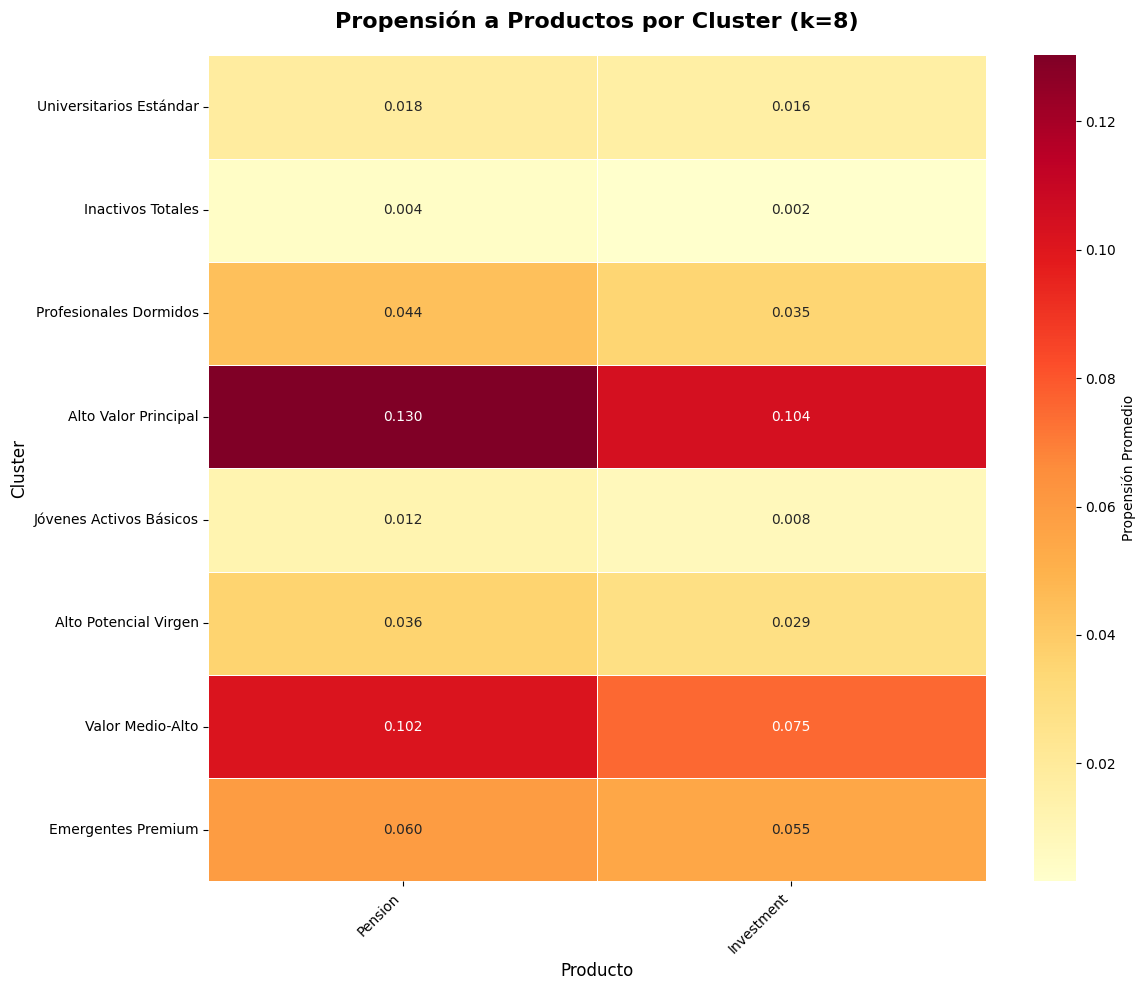

✅ Heatmap k=8 guardado


In [7]:
if propensity_cols and len(propensity_cols) > 0:
    heatmap_data = propensity_by_cluster.copy()
    heatmap_data.index = heatmap_data.index.get_level_values('cluster_name')
    heatmap_data.columns = [c.replace('propensity_', '').replace('_', ' ').title() for c in heatmap_data.columns]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='YlOrRd',
        cbar_kws={'label': 'Propensión Promedio'},
        linewidths=0.5
    )
    plt.title('Propensión a Productos por Cluster (k=8)', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Cluster', fontsize=12)
    plt.xlabel('Producto', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('../visualizations/propensity_heatmap_k8.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Heatmap k=8 guardado")

## 7. Distribuciones de Propensión (k=8)

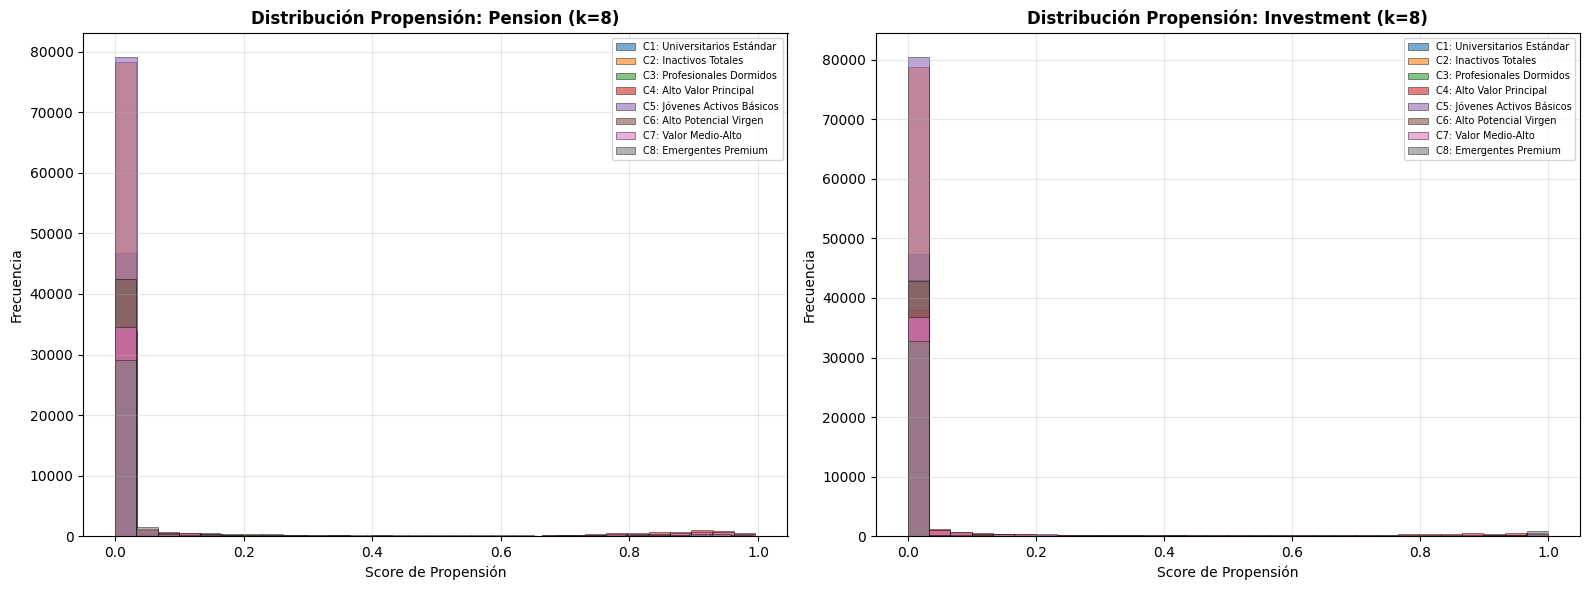

✅ Distribuciones k=8 guardadas


In [8]:
if propensity_cols:
    n_products = len(propensity_cols)
    n_cols = min(2, n_products)
    n_rows = (n_products + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
    if n_products == 1:
        axes = [axes]
    else:
        axes = axes.ravel()
    
    for idx, prop_col in enumerate(propensity_cols):
        ax = axes[idx]
        
        for cluster_id in sorted(df_combined['cluster'].unique()):
            cluster_data = df_combined[df_combined['cluster'] == cluster_id][prop_col].dropna()
            cluster_name = df_combined[df_combined['cluster']==cluster_id]['cluster_name'].iloc[0]
            
            ax.hist(
                cluster_data,
                alpha=0.6,
                label=f'C{cluster_id}: {cluster_name}',
                bins=30,
                edgecolor='black',
                linewidth=0.5
            )
        
        product_name = prop_col.replace('propensity_', '').replace('_', ' ').title()
        ax.set_title(f'Distribución Propensión: {product_name} (k=8)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Score de Propensión', fontsize=10)
        ax.set_ylabel('Frecuencia', fontsize=10)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)
    
    for idx in range(n_products, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('../visualizations/propensity_distributions_k8.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Distribuciones k=8 guardadas")

## 8. Top Clientes por Cluster y Producto (k=8)

In [9]:
if propensity_cols:
    top_n = 100
    
    for prop_col in propensity_cols:
        product_name = prop_col.replace('propensity_', '')
        top_customers = []
        
        for cluster_id in sorted(df_combined['cluster'].unique()):
            cluster_data = df_combined[df_combined['cluster'] == cluster_id].copy()
            cluster_data = cluster_data.dropna(subset=[prop_col])
            
            top_cluster = cluster_data.nlargest(top_n, prop_col)[['pk_cid', 'cluster', 'cluster_name', prop_col]]
            top_customers.append(top_cluster)
        
        df_top = pd.concat(top_customers, ignore_index=True)
        output_path = f'../data/top_customers_{product_name}_k8.csv'
        df_top.to_csv(output_path, index=False)
        print(f"✅ Top {len(df_top):,} clientes k=8 para {product_name}")
    
    print(f"\n📋 Archivos de targeting k=8 creados: {len(propensity_cols)}")

✅ Top 800 clientes k=8 para pension
✅ Top 800 clientes k=8 para investment

📋 Archivos de targeting k=8 creados: 2


## 9. Resumen Ejecutivo k=8

In [10]:
if propensity_cols:
    print("="*70)
    print("📊 RESUMEN: INTEGRACIÓN CLUSTERING k=8 + PROPENSIÓN")
    print("="*70)
    print()
    print(f"Total clientes: {len(df_combined):,}")
    print(f"Número de clusters: {df_combined['cluster'].nunique()}")
    print(f"Productos con propensión: {len(propensity_cols)}")
    print()
    print("="*70)
    print("🎯 RECOMENDACIONES POR CLUSTER (k=8)")
    print("="*70)
    
    for _, row in df_strategy.iterrows():
        print(f"\n{row['cluster_name']} (Cluster {row['cluster']}) - {row['size']:,} clientes")
        print(f"  └─ Producto recomendado: {row['recommended_product'].upper()}")
        print(f"     Propensión promedio: {row['max_propensity']:.2%}")
        print(f"     Conversiones estimadas: {int(row['size'] * row['max_propensity']):,}")
    
    print("\n" + "="*70)
    print("✅ ANÁLISIS k=8 COMPLETADO")
    print("="*70)

📊 RESUMEN: INTEGRACIÓN CLUSTERING k=8 + PROPENSIÓN

Total clientes: 442,909
Número de clusters: 8
Productos con propensión: 2

🎯 RECOMENDACIONES POR CLUSTER (k=8)

Universitarios Estándar (Cluster 1) - 49,104 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 1.84%
     Conversiones estimadas: 903

Inactivos Totales (Cluster 2) - 79,071 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 0.39%
     Conversiones estimadas: 310

Profesionales Dormidos (Cluster 3) - 48,934 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 4.42%
     Conversiones estimadas: 2,161

Alto Valor Principal (Cluster 4) - 52,933 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 13.03%
     Conversiones estimadas: 6,898

Jóvenes Activos Básicos (Cluster 5) - 81,893 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 1.19%
     Conversiones estimadas: 975

Alto Potencial Virgen (Cluster 6) - 45,095 clientes
  └─ Producto 

---

## ✅ INTEGRACIÓN k=8 COMPLETADA

### Archivos generados (con sufijo _k8):
1. propensity_by_cluster_k8.csv
2. product_strategy_by_cluster_k8.csv
3. top_customers_[producto]_k8.csv
4. Visualizaciones:
   - propensity_heatmap_k8.png
   - propensity_distributions_k8.png

### 🎉 TAREA 3 CLUSTERING OPTIMIZADA (k=8) COMPLETADA